# EDUNET FOUNDATION-Class Exercise Notebook

## LAB 1 - Demonstrating Logistic Regression on Diabetic dataset

## Ten baseline variables, age, sex, body mass index, average blood pressure, and six blood serum measurements were obtained for each of n = 442 diabetes patients, as well as the response of interest, a quantitative measure of disease progression one year after baseline.

Data Set Characteristics:

Number of Instances:
442

Number of Attributes:
First 10 columns are numeric predictive values

Target:
Column 11 is a quantitative measure of disease progression one year after baseline

Attribute Information:
age age in years

sex

bmi body mass index

bp average blood pressure

s1 tc, total serum cholesterol

s2 ldl, low-density lipoproteins

s3 hdl, high-density lipoproteins

s4 tch, total cholesterol / HDL

s5 ltg, possibly log of serum triglycerides level

s6 glu, blood sugar level

Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times the square root of n_samples (i.e. the sum of squares of each column totals 1).

## Step 1 : Import Necessary Libraries
## Step 2 : Load the Dataset and covert it in to Dataframe.
## Step 3 : Identify the Features and Target variable.
## Step 4 : Convert the target variable to binary (1 for diabetes, 0 for no diabetes).
            (by taking Median Value as a thesold value)
## Step 5 : Split the data into Training and testing
## Step 6 : Standardizing Features
## Step 7 : Create the Model
## Step 8 : Evaluating the Model
## Step 9 : Visualize the decision boundary with accuracy information
## Step 10 : Plot ROC Curve.


Importing Necessary Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


Loading the Dataset

In [3]:
# Load the diabetes dataset
diabetes = load_diabetes()

In [5]:
diabetes


{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [7]:
# Convert the dataset to a DataFrame
diabetes_sheet = pd.DataFrame(data=diabetes.data,
                           columns=diabetes.feature_names)
print(diabetes_sheet.head())

# Print the shape of the feature matrix and target vector
print("Shape of Sklearn Diabetes Data:", diabetes_sheet.shape)

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
Shape of Sklearn Diabetes Data: (442, 10)


In [9]:
#The Sklearn Diabetes Dataset include following attributes:

#age: Age in years
#sex: Gender of the patient
#bmi: Body mass index
#bp: Average blood pressure
#s1: Total serum cholesterol (tc)
#s2: Low-density lipoproteins (ldl)
#s3: High-density lipoproteins (hdl)
#s4: Total cholesterol / HDL (tch)
#s5: Possibly log of serum triglycerides level (ltg)
#s6: Blood sugar level (glu)

In [26]:
#Number of Instances: 442
#Number of Attributes: The first 10 columns are numeric predictive values.
#Target: Column 11 represents a quantitative measure of disease progression one year after baseline.

In [28]:
# Preprocessing the Dataset

In [13]:
X, y = diabetes.data, diabetes.target
print(X)
print(y)

# Convert the target variable to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

# It converts a continuous variable y into a binary classification variable y_binary using the following steps:

# np.median(y): This calculates the median of the array y.
# y > np.median(y): This compares each element of y with the median value. It returns a Boolean array 
# where each element is True if the corresponding element in y is greater than the median, 
# and False otherwise.
# .astype(int): Converts the Boolean values (True and False) to integers (1 and 0 respectively).
# So, after this operation:

# y_binary will be 1 for elements in y that are greater than the median.
# y_binary will be 0 for elements in y that are less than or equal to the median.


[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 

Splitting the Data

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
	X, y_binary, test_size=0.2, random_state=42)


Standardizing Features

In [36]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# scaler.fit_transform(X_train):

#  The fit_transform() method first calculates the necessary statistics 
#  (such as the mean and standard deviation for standardization, or min and max values for 
#  normalization) from the X_train data.Then, it transforms X_train based on these statistics. 
#  This ensures that the training data is scaled appropriately.

# scaler.transform(X_test): 

# After fitting the scaler on the training data, the transform() method applies the same scaling 
# to X_test, but without recalculating statistics. This ensures that the test data is transformed
# in the same way as the training data, maintaining consistency between the two datasets.

Training the Logistic Regression Model

In [19]:
# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Evaluating the Model

In [23]:
# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 74.16%


Detailed Model Evaluation

In [25]:
# evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[37 12]
 [11 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.76      0.76        49
           1       0.71      0.72      0.72        40

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



In [29]:
print(diabetes_sheet.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


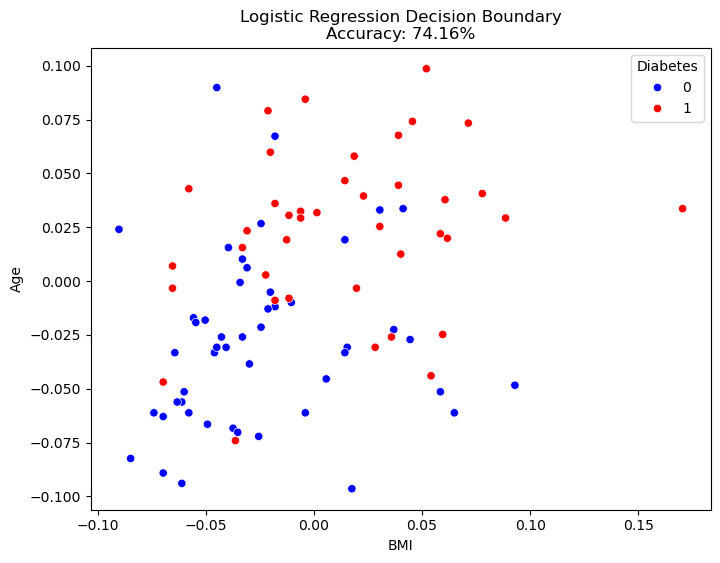

In [27]:
# Visualize the decision boundary with accuracy information
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test[:, 2], y=X_test[:, 8], hue=y_test, palette={
				0: 'blue', 1: 'red'}, marker='o')
plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("Logistic Regression Decision Boundary\nAccuracy: {:.2f}%".format(
	accuracy * 100))
plt.legend(title="Diabetes", loc="upper right")
plt.show()


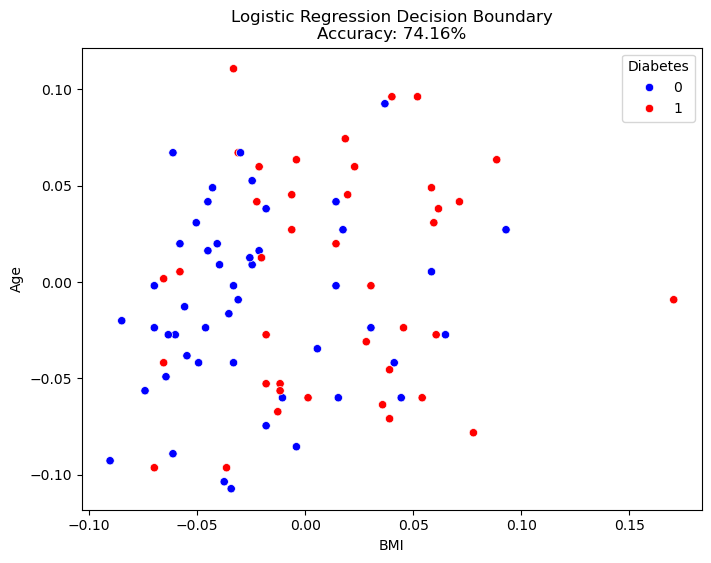

In [45]:
# Visualize the decision boundary with accuracy information
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test[:, 2], y=X_test[:, 0], hue=y_test, palette={
				0: 'blue', 1: 'red'}, marker='o')

# x=X_test[:, 2]: Selects the feature (column) at index 2 from X_test for the x-axis.
# y=X_test[:, 4]: Selects the feature (column) at index 4 from X_test for the y-axis.
# hue=y_test: Colors the points according to the values in y_test, which is presumably the true binary
# labels (e.g., 0 and 1).
# palette={0: 'blue', 1: 'red'}: Assigns specific colors to the two classes: class 0 is blue, and class
# 1 is red.
# marker='o': Specifies the shape of the markers as circles ('o').

plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("Logistic Regression Decision Boundary\nAccuracy: {:.2f}%".format(
	accuracy * 100))
plt.legend(title="Diabetes", loc="upper right")
plt.show()


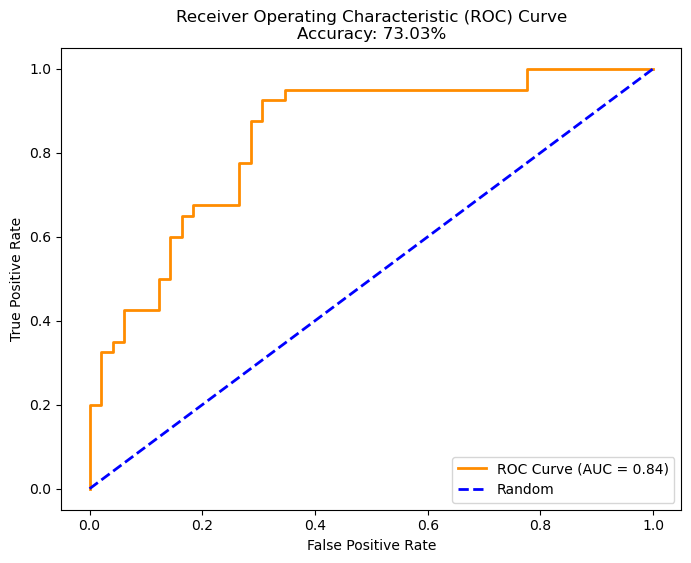

In [60]:
# Plot ROC Curve

y_prob = model.predict_proba(X_test)[:, 1]
# The line y_prob = model.predict_proba(X_test)[:, 1] extracts the predicted probabilities of a 
# binary classification model for the positive class.

# model.predict_proba(X_test) returns a 2D array where each row corresponds to a sample in X_test  and
# the columns represent the predicted probabilities for each class (0 and 1 in binary classification).
# [:, 1] slices the array to get the probabilities for the positive class (class 1).
#As a result, y_prob will contain an array of probabilities that indicate the likelihood of each sample
#in X_test belonging to the positive class.


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# function Signature : fpr, tpr, thresholds = roc_curve(y_true, y_score)

roc_auc = auc(fpr, tpr)

# It calculates the Area Under the Curve (AUC) for the ROC curve by using the auc() function from
# scikit-learn, which computes the AUC given the False Positive Rate (FPR) and True Positive Rate (TPR).

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')

# label=f'ROC Curve (AUC = {roc_auc:.2f})': Adds a label to the ROC curve. 
# The label includes the AUC value (roc_auc), formatted to 2 decimal places using f-string formatting
# in Python ({roc_auc:.2f}). This label will be displayed in the plot’s legend.

plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--', label='Random')

# Plots a diagonal line from (0, 0) to (1, 1), representing the performance of a random classifier.

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve\nAccuracy: {:.2f}%'.format(
	accuracy * 100))
plt.legend(loc="lower right")
plt.show()
